# Optimized+augmented PyTorch CNN

In this notebook, we train the winning CNN architecture from the Optuna run in notebook 04, using the optimized training strategy from notebook 05, on the CIFAR-10 dataset with image augmentation for improved generalization.

## Notebook set-up

### Imports

In [1]:
# Standard library imports
import pickle

# Third party imports
import matplotlib.pyplot as plt
import numpy as np
import optuna
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms

# Package imports
from image_classification_tools.pytorch import DataPipeline, AugmentationStrategy
import image_classification_tools.pytorch.evaluation as eval_utils
import image_classification_tools.pytorch.hyperparameter_optimization as optimization
import image_classification_tools.pytorch.plotting as plots
import image_classification_tools.pytorch.training as training

# Local imports
import configuration as config
import helper_functions as hf

Using device: cuda


### Configuration

In [2]:
# Model control
retrain_model = False        # Set to False to load existing model
model_source = 'huggingface' # 'local' or 'huggingface'

# Data loading
preload_device = 'gpu' if torch.cuda.is_available() else 'cpu'

# Optuna study configuration
study_storage = 'sqlite:///../data/pytorch/cnn_optimization.db'

### Hyperparameters

In [3]:
# Data augmentation
augmentation_depth = 5  # Number of augmented copies per training image

# Training settings
epochs = 500
early_stopping_patience = 15
print_every = 10

## 1. Load optimization results

In [4]:
# Load architecture optimization study from notebook 04
architecture_study = optuna.load_study(
    study_name='architecture_optimization',
    storage=study_storage
)

# Get best architecture parameters
arch_params = architecture_study.best_trial.params

print('Best architecture hyperparameters from notebook 04:\n')

for key, value in arch_params.items():
    print(f'  {key}: {value}')

print(f'\nBest validation accuracy: {architecture_study.best_value:.2f}%')

# Load training optimization study from notebook 05
training_study = optuna.load_study(
    study_name='training_optimization',
    storage=study_storage
)

# Get best training parameters
training_params = training_study.best_trial.params

print('\nBest training hyperparameters from notebook 05:\n')

for key, value in training_params.items():
    print(f'  {key}: {value}')

print(f'\nBest validation accuracy: {training_study.best_value:.2f}%')

# Get batch size from architecture optimization
batch_size = arch_params['batch_size']


Best architecture hyperparameters from notebook 04:

  batch_size: 256
  n_conv_blocks: 7
  initial_filters: 64
  n_fc_layers: 1
  conv_dropout_rate: 0.3970168590808983
  fc_dropout_rate: 0.41794948916615016
  pool_frequency: 4
  filter_double_frequency: 3
  learning_rate: 0.0003262697843356068

Best validation accuracy: 88.79%

Best training hyperparameters from notebook 05:

  optimizer: SGD
  learning_rate: 0.010258532143373404
  weight_decay: 0.0021674627774374913
  label_smoothing: 0.003165204969827274
  lr_scheduler: step
  momentum: 0.9560066692269822
  nesterov: True

Best validation accuracy: 91.57%


## 2. Create data pipeline with pregenerated augmentation

In [5]:
# Create data pipeline with pregenerated augmentation
loaders = DataPipeline(
    data_source=datasets.CIFAR10,
    split='train/val/test',
    train_transform=config.RGB_TRANSFORM,
    eval_transform=config.RGB_TRANSFORM,
    augmentation=AugmentationStrategy.PREGENERATED,
    pil_augmentations=config.PIL_AUGMENTATIONS,
    tensor_augmentations=config.TENSOR_AUGMENTATIONS,
    n_augmentations=augmentation_depth,
    preload=preload_device,
    batch_size=batch_size,
    val_size=config.VAL_SIZE,
    seed=config.SEED,
    cache_key=config.AUGMENTATION_CACHE_KEY,
    root=config.DATA_DIR
).get_loaders()

# Display pipeline summary
print(f'Batch sizes: {loaders.get_batch_sizes()}')
print(f'Total samples: {loaders.total_samples()}')

memory_estimate = loaders.memory_estimate()

if memory_estimate is not None:
    print(f'Memory estimate: {memory_estimate:.2f} GB')

else:
    print('Memory estimate: N/A')

# Unpack loaders for convenience
train_loader = loaders.train
val_loader = loaders.val
test_loader = loaders.test

Loading train dataset...
Loading test dataset...
Creating splits...

Applying pregenerated augmentation...
Loading cached augmented data from ../data/pytorch/cifar10/augmented_cache/cifar10_standard_aug_v1
Preloading train to GPU:0...


Preloading train: 100%|██████████| 200000/200000 [00:02<00:00, 71770.78it/s]


Preloading val to GPU:0...


Preloading val: 100%|██████████| 10000/10000 [00:03<00:00, 2716.06it/s]


Batch sizes: {'train': 256, 'val': 256, 'test': 256}
Total samples: {'train': 200000, 'val': 10000, 'test': 10000}
Memory estimate: 2.52 GB


### 2.1. Upload augmented dataset to HuggingFace (optional)

In [6]:
# Upload augmented dataset to HuggingFace if configured
# The augmented data is cached in data/pytorch/cifar10_augmented/
augmented_data_path = config.DATA_DIR / 'pytorch' / 'cifar10_augmented'

if hf.should_upload_to_huggingface() and augmented_data_path.exists():
    print(f'Uploading augmented dataset to HuggingFace...')
    print(f'  Source: {augmented_data_path}')
    print(f'  This may take a while for large datasets...\n')
    
    # Upload the entire augmented dataset directory to datasets/ subdirectory
    result = hf.upload_to_huggingface(
        model_path=augmented_data_path,
        model_name='cifar10_augmented',
        commit_message=f'Upload augmented CIFAR-10 dataset (depth={augmentation_depth})',
        path_in_repo='datasets/cifar10_augmented'
    )
    
    if result:
        print('Augmented dataset uploaded successfully!')

    else:
        print('Failed to upload augmented dataset')
else:
    if not hf.should_upload_to_huggingface():
        print('Skipping upload - HuggingFace credentials not configured')

    elif not augmented_data_path.exists():
        print(f'Augmented data not found at: {augmented_data_path}')

Augmented data not found at: ../data/pytorch/cifar10/pytorch/cifar10_augmented


## 3. Build optimized CNN using best hyperparameters

Create a CNN using the best hyperparameters found during Optuna optimization, then train it with pre-augmented data.

In [7]:
# Define model path
model_path = config.MODELS_DIR / '06-augmented_cnn.pth'

# Load existing model if requested
if not retrain_model:

    model = hf.load_model_from_source(
        model_path=model_path,
        model_name='06-augmented_cnn.pth',
        model_source=model_source,
        device=config.DEVICE
    )
    
    # Try to load training history
    history = hf.load_history_from_source(
        model_path=model_path,
        model_name='06-augmented_cnn.pth',
        model_source=model_source
    )
    
    if model is None:
        print('Pretrained model not available, proceeding with training...')
        retrain_model = True

else:
    print('Training new model...')
    history = None

augmented_cnn.pth:   0%|          | 0.00/7.74M [00:00<?, ?B/s]

Model downloaded from Hugging Face


augmented_cnn_history.json: 0.00B [00:00, ?B/s]

Training history downloaded from Hugging Face


### 3.1. Create model with best hyperparameters

In [8]:
def create_optimized_cnn(num_classes, in_channels, arch_params):
    '''Create CNN with best architecture from notebook 04.
    
    Args:
        num_classes: Number of output classes
        in_channels: Number of input channels (3 for RGB)
        arch_params: Architecture parameters from Optuna study
    
    Returns:
        nn.Sequential model
    '''
    
    # Extract architecture parameters
    n_conv_blocks = arch_params['n_conv_blocks']
    initial_filters = arch_params['initial_filters']
    n_fc_layers = arch_params['n_fc_layers']
    conv_dropout_rate = arch_params['conv_dropout_rate']
    fc_dropout_rate = arch_params['fc_dropout_rate']
    pool_frequency = arch_params.get('pool_frequency', 2)
    filter_double_frequency = arch_params.get('filter_double_frequency', 2)
    
    layers = []
    current_channels = in_channels
    spatial_size = 32  # CIFAR-10 input size
    
    # Convolutional blocks
    for block_idx in range(n_conv_blocks):

        # Double filters every N blocks
        out_channels = initial_filters * (2 ** (block_idx // filter_double_frequency))
        
        # First conv in block
        layers.append(nn.Conv2d(current_channels, out_channels, kernel_size=3, padding=1))
        layers.append(nn.BatchNorm2d(out_channels))
        layers.append(nn.ReLU())
        
        # Second conv in block
        layers.append(nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1))
        layers.append(nn.BatchNorm2d(out_channels))
        layers.append(nn.ReLU())
        
        # Pool every N blocks
        should_pool = (block_idx + 1) % pool_frequency == 0

        if should_pool and spatial_size > 1:
            layers.append(nn.MaxPool2d(2, 2))
            spatial_size //= 2
        
        layers.append(nn.Dropout(conv_dropout_rate))
        current_channels = out_channels
    
    # Classifier with adaptive pooling
    layers.append(nn.AdaptiveAvgPool2d((1, 1)))
    layers.append(nn.Flatten())
    
    # Generate FC layer sizes
    fc_sizes = []
    current_fc_size = current_channels // 2

    for _ in range(n_fc_layers):
        fc_sizes.append(max(32, current_fc_size))
        current_fc_size //= 2
    
    # Add FC layers
    in_features = current_channels

    for fc_size in fc_sizes:
        layers.append(nn.Linear(in_features, fc_size))
        layers.append(nn.ReLU())
        layers.append(nn.Dropout(fc_dropout_rate))
        in_features = fc_size
    
    # Output layer
    layers.append(nn.Linear(in_features, num_classes))
    
    return nn.Sequential(*layers)

In [9]:
if retrain_model:

    # Create model with best architecture from notebook 04
    model = create_optimized_cnn(
        num_classes=len(config.CLASS_NAMES),
        in_channels=3,
        arch_params=arch_params
    ).to(config.DEVICE)

    # Show model architecture
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f'\n{model}')
    print(f'\nTotal parameters: {total_params:,}')
    print(f'Trainable parameters: {trainable_params:,}')

else:
    # Use the loaded model
    print('Using loaded model')
    print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')

Using loaded model

Total parameters: 1,920,970


### 3.2. Define loss function and optimizer

In [10]:
if retrain_model:

    # Create optimizer with best training parameters from notebook 05
    optimizer_name = training_params['optimizer']
    learning_rate = training_params['learning_rate']
    weight_decay = training_params['weight_decay']
    
    if optimizer_name == 'Adam':
        optimizer = optim.Adam(
            model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay
        )

    elif optimizer_name == 'AdamW':
        optimizer = optim.AdamW(
            model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay
        )

    elif optimizer_name == 'SGD':
        optimizer = optim.SGD(
            model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay,
            momentum=0.9
        )
    
    # Set cross-entropy loss
    criterion = nn.CrossEntropyLoss()

### 3.3. Train the model

In [11]:
%%time

if retrain_model:

    # Train model
    history = training.train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=config.DEVICE,
        epochs=epochs,
        print_every=print_every,
        enable_early_stopping=True,
        early_stopping_patience=early_stopping_patience
    )

    print()

else:
    print('Training skipped - using loaded model\n')

Training skipped - using loaded model

CPU times: user 660 µs, sys: 0 ns, total: 660 µs
Wall time: 481 µs


### 3.4. Learning curves

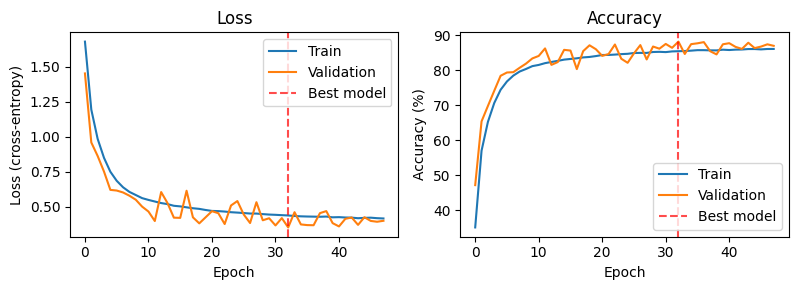

In [12]:
fig, axes = plots.plot_learning_curves(history)
plt.show()

## 4. Evaluate model on test set

### 4.1. Calculate test accuracy

In [13]:
test_accuracy, predictions, true_labels = eval_utils.evaluate_model(model, test_loader)
print(f'Test accuracy: {test_accuracy:.2f}%')

Test accuracy: 87.35%


### 4.2. Per-class accuracy

In [14]:
# Calculate per-class accuracy
class_correct = {name: 0 for name in config.CLASS_NAMES}
class_total = {name: 0 for name in config.CLASS_NAMES}

for pred, true in zip(predictions, true_labels):

    class_name = config.CLASS_NAMES[true]
    class_total[class_name] += 1

    if pred == true:
        class_correct[class_name] += 1

print('Per-class accuracy:')
print('-' * 30)

for name in config.CLASS_NAMES:
    acc = 100 * class_correct[name] / class_total[name]
    print(f'{name:12s}: {acc:.2f}%')

Per-class accuracy:
------------------------------
airplane    : 85.70%
automobile  : 96.80%
bird        : 87.90%
cat         : 68.30%
deer        : 92.10%
dog         : 80.60%
frog        : 85.40%
horse       : 89.60%
ship        : 96.00%
truck       : 91.10%


### 4.3. Confusion matrix

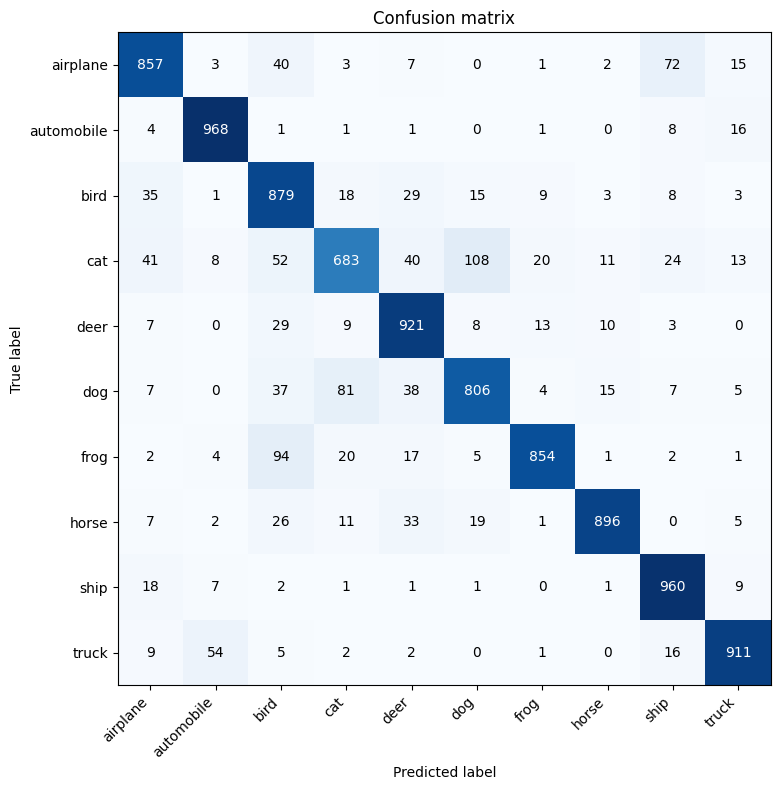

In [15]:
fig, ax = plots.plot_confusion_matrix(true_labels, predictions, config.CLASS_NAMES)
plt.show()

### 4.4. Predicted class probability distributions

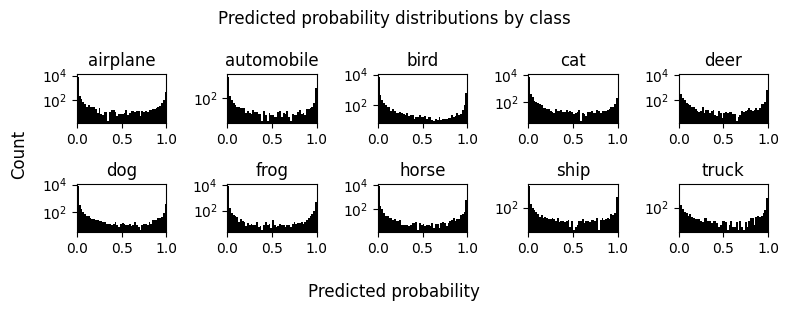

In [16]:
# Get predicted probabilities for all test samples
model.eval()
all_probs = []

with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(config.DEVICE, non_blocking=True)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        all_probs.append(probs.cpu().numpy())

all_probs = np.concatenate(all_probs, axis=0)

# Plot probability distributions
fig, axes = plots.plot_class_probability_distributions(all_probs, config.CLASS_NAMES)
plt.show()

### 4.5. Evaluation curves

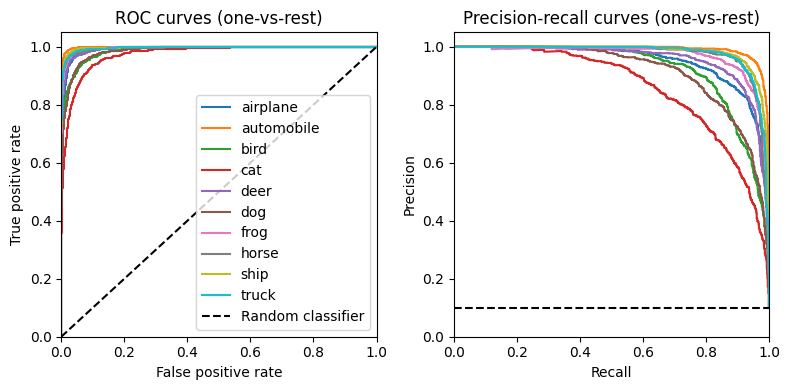

In [17]:
fig, (ax1, ax2) = plots.plot_evaluation_curves(true_labels, all_probs, config.CLASS_NAMES)
plt.show()

## 5. Save model

In [18]:
if retrain_model:

    # Save trained model (and auto-upload to Hugging Face if configured)
    hf.save_and_upload_model(
        model=model,
        model_path=model_path,
        model_name='06-augmented_cnn.pth',
        history=history
    )

## 6. Save test results for comparison

In [19]:
# Save results path
results_path = config.RESULTS_DIR / 'augmented_cnn_results.pkl'

# Count model parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

# Create results dictionary
results_dict = {
    'true_labels': true_labels,
    'predictions': predictions,
    'all_probs': all_probs,
    'test_accuracy': test_accuracy,
    'total_params': total_params,
    'trainable_params': trainable_params
}

# Save results
with open(results_path, 'wb') as f:
    pickle.dump(results_dict, f)

print(f'Test results saved to: {results_path}')
print(f'  - Test accuracy: {test_accuracy:.2f}%')
print(f'  - Total parameters: {total_params:,}')
print(f'  - Trainable parameters: {trainable_params:,}')

Test results saved to: ../data/pytorch/performance_results/augmented_cnn_results.pkl
  - Test accuracy: 87.35%
  - Total parameters: 1,920,970
  - Trainable parameters: 1,920,970
